# Golden Pipelines (`aap`)

AAanalysis has two interfaces. The **explicit** interface (`import aaanalysis as aa`) exposes every object and step for full control; the **golden-pipeline** interface (`import aaanalysis.pipe as aap`) wraps the standard workflow into one call each — much as `pyplot` sits over Matplotlib's objects.

This tutorial tours the four **golden pipelines** along the analysis spine and explains **every output** each one returns:

1. **`obtain_samples`** — *Sample*: turn a sampling situation into a balanced, labeled training set.
2. **`find_features`** — *Identify*: a CPP AutoML search for the discriminating feature signature, with publication-ready evaluation figures.
3. **`predict_samples`** — *Predict*: train and compare predictors across feature sets and models.
4. **`explain_features`** — *Explain* (*pro*): per-sample SHAP feature impact.

Every pipeline returns the uniform triple `(results, figs, evals)` — a result, an optional figure, and an optional evaluation table. Steps 2–4 chain on one domain-level dataset (`DOM_GSEC`); step 1 is shown on its own, since it addresses residue-level window sampling.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import aaanalysis as aa
import aaanalysis.pipe as aap

aa.options["verbose"] = False
aa.plot_settings()
# Silence the small-demo-data advisory (the toy set can't always supply larger n_filter values).
warnings.filterwarnings("ignore", message=r"'n_filter'", category=RuntimeWarning)

## 1. `obtain_samples` — build a training set

`obtain_samples` wraps :class:`AAWindowSampler` (and, on the positive-unlabeled path, :class:`dPULearn`): the parameters simply **describe the sampling situation**. It is a *residue-level* step — known positives are 1-based anchors in a position column, and balancing reference windows are drawn around them. We mark a positive anchor at the centre of each substrate; non-substrates form the unlabeled pool:

In [2]:
df_seq_res = aa.load_dataset(name="DOM_GSEC", n=20)[["entry", "sequence", "label"]].copy()
df_seq_res["pos"] = (df_seq_res["sequence"].str.len() // 2).astype(int)
df_seq_res.loc[df_seq_res["label"] == 0, "pos"] = np.nan   # no positive -> unlabeled pool

df_samples, ax, df_eval_sample = aap.obtain_samples(df_seq_res, strategy="same_protein",
                                                    n=20, window_size=9, seed=42)

aa.display_df(df_samples, n_rows=10, show_shape=True)

DataFrame shape: (40, 8)


,entry_win,entry,sequence,window,source_position,label,role,strategy
1,P05067_381-389,P05067,MLPGLALLLLAAWTA...GYENPTYKFFEQMQN,TPGDENEHA,385,1,Test,test
2,P14925_484-492,P14925,MAGRARSGLLLLLLG...EEEYSAPLPKPAPSS,QQPGEGPWE,488,1,Test,test
3,P70180_264-272,P70180,MRSLLLFTFSACVLL...RELREDSIRSHFSVA,RIMLAVHRH,268,1,Test,test
4,Q03157_323-331,Q03157,MGPTSPAARGQGRRW...HGYENPTYRFLEERP,ERRMRQINE,327,1,Test,test
5,Q06481_377-385,Q06481,MAATGTAAAAATGRL...GYENPTYKYLEQMQI,YFETSADDN,381,1,Test,test
6,P35613_188-196,P35613,MAAALFVLLGFALLG...HQNDKGKNVRQRNSS,TEFKVDSDD,192,1,Test,test
7,P35070_85-93,P35070,MDRAARCSGASSLPL...DITPINEDIEETNIA,VVAEQTPSC,89,1,Test,test
8,P09803_438-446,P09803,MGARCRSFSALLLLL...RFKKLADMYGGGEDD,LKTAKGLDF,442,1,Test,test
9,P19022_449-457,P19022,MCRIAGALRTLLPLL...PRFKKLADMYGGGDD,PIDFETNRM,453,1,Test,test
10,P16070_367-375,P16070,MDKFWWHAAWGLCLV...DETRNLQNVDMKIGV,LIHHEHHEE,371,1,Test,test


**Output 1 — `df_samples`** is a `'segments'`-mode training set, ready to feed the next pipeline. Each row is one window with its `label` (1 = positive `Test`, 0 = sampled reference), its `role` (`Test` / `Negative`), and its `strategy` (which sampler produced it) — full provenance.

**Output 3 — `df_eval`** is the validation report: class balance, the number of source proteins, protein coverage, and the maximum identity of any sampled window to a test window (the leakage indicator — lower is safer):

In [3]:
aa.display_df(df_eval_sample, n_rows=10, show_shape=True)

DataFrame shape: (1, 6)


,n_positive,n_negative,balance_ratio,n_source_proteins,protein_coverage,max_similarity_to_test
1,20,20,1.000000,20,0.500000,0.333333


## 2. `find_features` — identify the signature

From here we use the domain-level `DOM_GSEC` set (substrates vs non-substrates, already labeled). `find_features` runs a staged **CPP AutoML** search: it sweeps the Part × Split × Scale feature space, selects the configuration with the best cross-validated model performance, refines it, and scores feature importance. With `plot=True` it draws the CPP **feature map** and attaches **publication-ready evaluation figures** as `ax.eval`:

feature map + 3 evaluation figures (ax.eval)


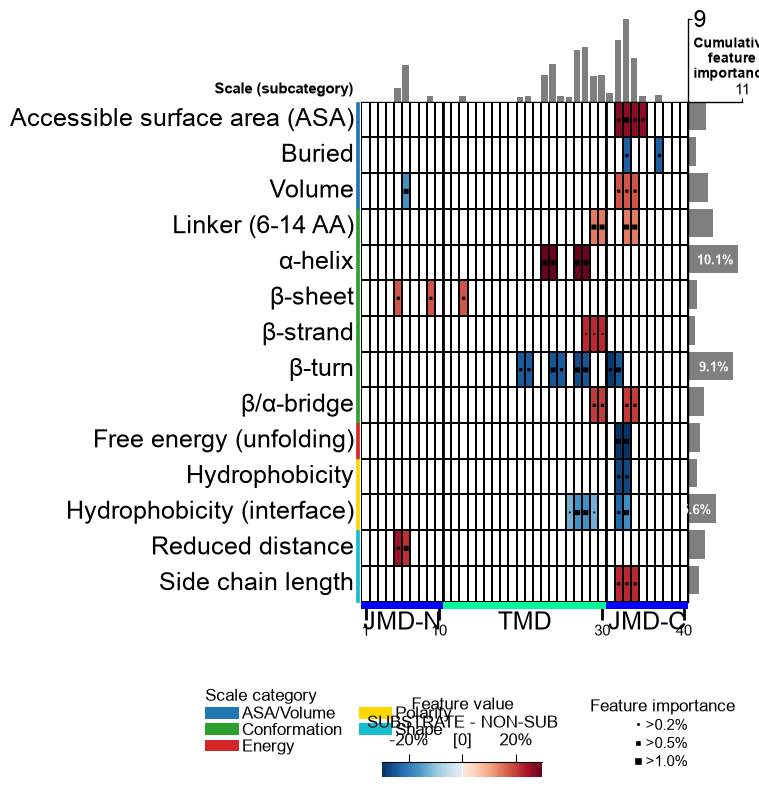

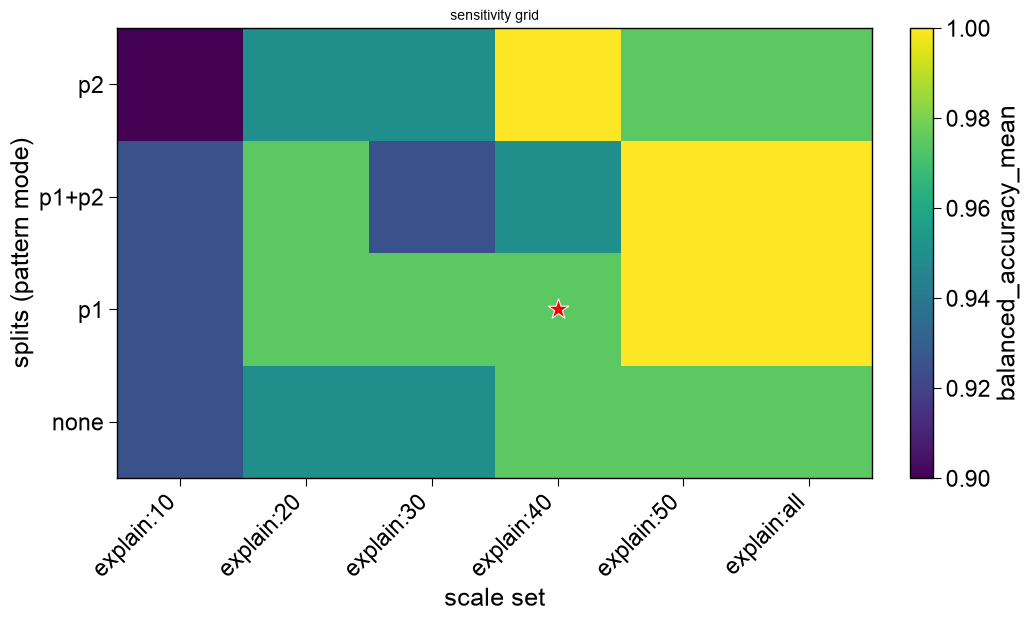

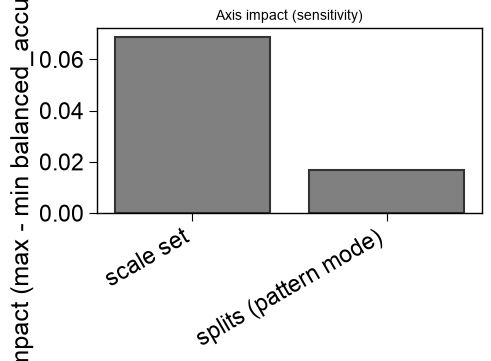

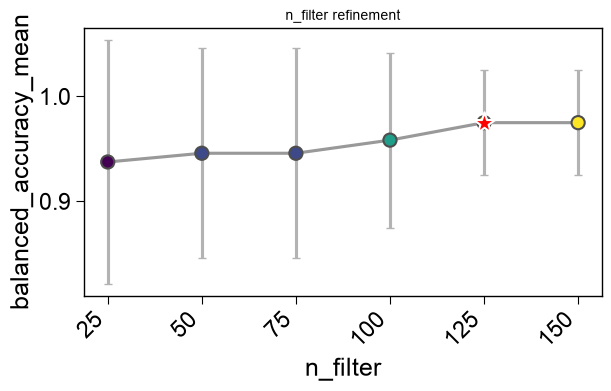

In [4]:
df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()

df_feat, ax, df_eval_find = aap.find_features(labels=labels, df_seq=df_seq, search="balanced",
                                              kws={"n_split_max": 15}, top_n=25, plot=True,
                                              name_test="SUBSTRATE", name_ref="NON-SUB",
                                              random_state=42, n_jobs=1)

print(f"feature map + {len(ax.eval)} evaluation figures (ax.eval)")
plt.show()

**Output 1 — `df_feat`** is the discovered signature: one row per selected feature (`PART-SPLIT-SCALE`), with its scale metadata, group statistics (`abs_auc`, `mean_dif`, ...), and `feat_importance`. This is the artifact the next two pipelines consume:

In [5]:
aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (25, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD-Pattern(C,4,8)-BEGF750101",Conformation,α-helix,α-helix,"Conformational ...in-Dirkx, 1975)",0.444000,0.299000,0.299000,0.090000,0.196000,0.000002,0.029764,"23,27",5.717000,0.000000
2,"TMD_C_JMD_C-Pat...4,8)-BEGF750101",Conformation,α-helix,α-helix,"Conformational ...in-Dirkx, 1975)",0.444000,0.299000,0.299000,0.090000,0.196000,0.000002,0.014882,"24,28",4.386000,0.000000
3,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",Conformation,β-turn,β-turn,"Normalized freq...d et al., 1973)",0.431000,0.251000,-0.251000,0.088000,0.143000,0.000003,0.007247,"24,28,32",4.053000,0.000000
4,"TMD_C_JMD_C-Pat...,14)-GEOR030103",Conformation,Linker (6-14 AA),Linker (2),"Linker propensi...-Heringa, 2003)",0.321000,0.141000,0.141000,0.112000,0.138000,0.000509,0.008954,"30,34",2.999000,0.000000
5,"TMD_C_JMD_C-Seg...5,7)-CHOC760101",ASA/Volume,Volume,Accessible surface area (ASA),"Residue accessi...(Chothia, 1976)",0.365000,0.173000,0.173000,0.113000,0.112000,0.000078,0.008365,"32,33,34",2.640000,0.000000
6,"TMD-Segment(10,11)-CHAM820102",Polarity,Hydrophobicity (interface),Free energy (interface),"Free energy of ...-Charton, 1982)",0.389000,0.169000,-0.169000,0.050000,0.130000,0.000026,0.008757,"27,28",2.608000,0.000000
7,"TMD_C_JMD_C-Seg...6,9)-YUTK870102",Energy,Free energy (unfolding),Free energy (unfolding),"Unfolding Gibbs...i et al., 1987)",0.380000,0.295000,-0.295000,0.195000,0.154000,0.000039,0.008339,"32,33",2.365000,0.000000
8,"TMD_C_JMD_C-Seg...5,7)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.377000,0.220000,0.220000,0.157000,0.144000,0.000044,0.008600,"32,33,34",2.228000,0.000000
9,"TMD_C_JMD_C-Pat...,12)-GEOR030103",Conformation,Linker (6-14 AA),Linker (2),"Linker propensi...-Heringa, 2003)",0.321000,0.141000,0.141000,0.112000,0.138000,0.000509,0.008863,"29,33",2.134000,0.000000
10,"TMD_C_JMD_C-Seg...6,8)-GUYH850105",ASA/Volume,Accessible surface area (ASA),Partition energy,"Apparent partit...dex (Guy, 1985)",0.330000,0.263000,0.263000,0.196000,0.224000,0.000356,0.008726,"33,34,35",2.023000,0.000000


**Output 3 — `df_eval`** is the sweep table (one row per evaluated configuration): the configuration descriptors, one `<metric>_mean` / `<metric>_std` column per metric, the `stage`, `is_pareto` (Pareto-optimal within its stage), and `is_selected` (the single winner). The eval figures above (`ax.eval`) are this table's visual form — `viridis` heatmaps of the two most-informative axes, plus marginal-impact and `n_filter` panels; each can be saved for a paper with `ax.eval[i].savefig(...)`:

In [6]:
aa.display_df(df_eval_find, n_rows=10, show_shape=True)

DataFrame shape: (61, 13)


,stage,list_parts,split_types,pattern_mode,n_split_max,scale,n_filter,n_features,balanced_accuracy_mean,balanced_accuracy_std,is_pareto,is_selected,rank
1,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,150,150,1.000000,0.000000,True,False,1
2,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:all,150,150,1.000000,0.000000,True,False,2
3,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,explain:40,150,150,1.000000,0.000000,True,False,3
4,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,explain:50,150,150,1.000000,0.000000,True,False,4
5,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,explain:all,150,150,1.000000,0.000000,True,False,5
6,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:40,125,125,1.000000,0.000000,True,False,6
7,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,125,125,1.000000,0.000000,True,False,7
8,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,150,150,1.000000,0.000000,True,False,8
9,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:all,150,150,1.000000,0.000000,True,False,9
10,refine,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:40,125,91,1.000000,0.000000,True,True,10


## 3. `predict_samples` — train and compare predictors

We feed the discovered `df_feat` straight into `predict_samples`. It crosses every **feature set** with every **model** (here the default core set — random forest, extra trees, SVM, logistic regression), cross-validates each, and refits it on all samples:

In [7]:
predictors, figs, df_eval_pred = aap.predict_samples(df_feat, df_seq, labels=labels,
                                                     random_state=42)

aa.display_df(df_eval_pred, n_rows=10, show_shape=True)

DataFrame shape: (4, 17)


/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programm

,feature_set,model,n_features,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std,is_shap_ready,is_best
1,features,RandomForest,25,0.900000,0.093541,0.900000,0.093541,0.909206,0.079418,0.893333,0.137275,0.950000,0.100000,0.987500,0.025000,True,False
2,features,ExtraTrees,25,0.925000,0.100000,0.925000,0.100000,0.931429,0.085905,0.933333,0.133333,0.950000,0.100000,0.987500,0.025000,True,False
3,features,SVM,25,0.950000,0.100000,0.950000,0.100000,0.950000,0.100000,0.950000,0.100000,0.950000,0.100000,0.975000,0.050000,False,False
4,features,LogReg,25,0.975000,0.050000,0.975000,0.050000,0.977778,0.044444,0.960000,0.080000,1.000000,0.000000,0.987500,0.025000,False,True


**Output 3 — `df_eval`** is the comparison table, one row per `(feature_set, model)`:

- `feature_set` / `model` — the combination's names (also the keys of `predictors`).
- `n_features` — features in that set.
- `<metric>_mean` / `<metric>_std` — cross-validated mean ± std of `balanced_accuracy` (the headline), `accuracy`, `f1`, `precision`, `recall`, `roc_auc`.
- `is_shap_ready` — the predictor exposes feature importances (tree-based), so it can feed `explain_features`.
- `is_best` — the single highest `balanced_accuracy_mean` row.

**Output 1 — `predictors`** is a dict keyed `(feature_set, model)`; pick the best by its `is_best` row. (`figs` is `None` — prediction draws no plot.)

In [8]:
best = df_eval_pred[df_eval_pred["is_best"]].iloc[0]
print(f"best: {best['model']}  (bACC={best['balanced_accuracy_mean']:.3f})")
print("predictor keys:", list(predictors))
best_predictor = predictors[(best["feature_set"], best["model"])]
print("best predictor:", type(best_predictor).__name__)

best: LogReg  (bACC=0.975)
predictor keys: [('features', 'RandomForest'), ('features', 'ExtraTrees'), ('features', 'SVM'), ('features', 'LogReg')]
best predictor: LogisticRegression


## 4. `explain_features` — per-sample SHAP impact (*pro*)

Finally, `explain_features` (requires `aaanalysis[pro]`) fits a :class:`ShapModel` on the same `df_feat`, attaches per-sample SHAP feature impact to it, and draws the SHAP-coloured feature map. By default it explains the single most confidently predicted sample:

SHAP impact columns added to df_feat: ['feat_impact_P09803'] | evals: None


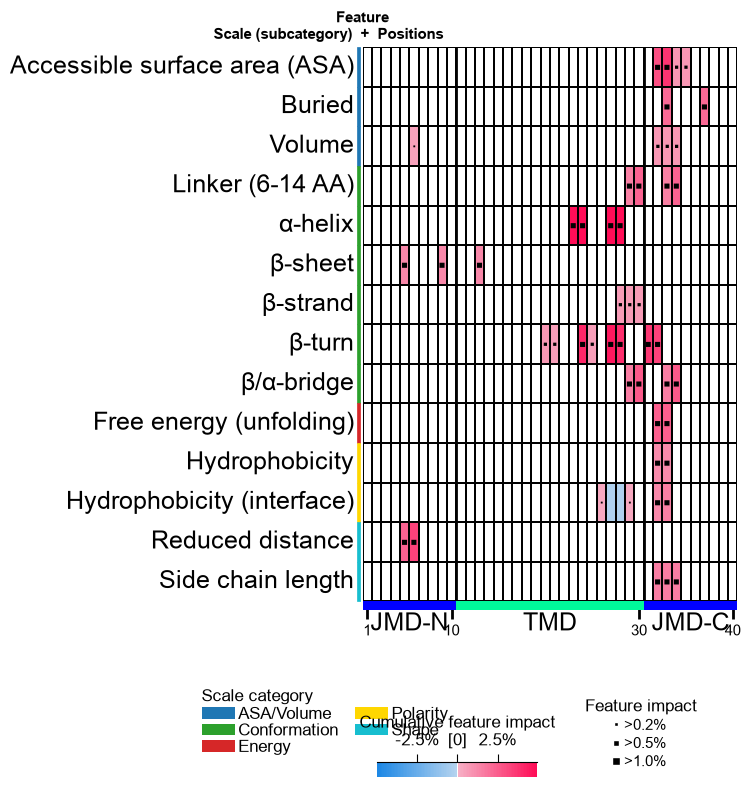

In [9]:
df_shap, ax, evals = aap.explain_features(df_feat, df_seq, labels,
                                          name_test="SUBSTRATE", name_ref="NON-SUB",
                                          random_state=42, n_jobs=1)

impact_cols = [c for c in df_shap.columns if c.startswith("feat_impact_")]
print("SHAP impact columns added to df_feat:", impact_cols, "| evals:", evals)
plt.show()

**Output 1 — `df_shap`** is `df_feat` with a signed `feat_impact_'entry'` column per explained sample (the per-feature SHAP value); the feature map colours each feature by that impact. `evals` is `None` — explanation does no evaluation.

## The spine

That is the full golden-pipeline spine — **`obtain_samples` → `find_features` → `predict_samples` → `explain_features`** — each a single call returning the uniform `(results, figs, evals)` triple. For fine-grained control of any step, drop to the explicit `aa` objects (`AAWindowSampler`, `CPP`, `TreeModel`, `ShapModel`) covered in the per-tool tutorials.